The data has been cleaned and saved as cleaned_discipline_specific_pathways.csv!
       # Awardees w/ This Award  Percentage of Awardees with This Award  \
count             304599.000000                           304599.000000   
mean                   1.283166                                0.542039   
std                    1.677693                                0.392523   
min                    1.000000                                0.002000   
25%                    1.000000                                0.167000   
50%                    1.000000                                0.500000   
75%                    1.000000                                1.000000   
max                  154.000000                                1.000000   

       Mean Academic Age at Time of Award  
count                       304599.000000  
mean                            16.557072  
std                             11.309291  
min                              0.000000  
25%                    

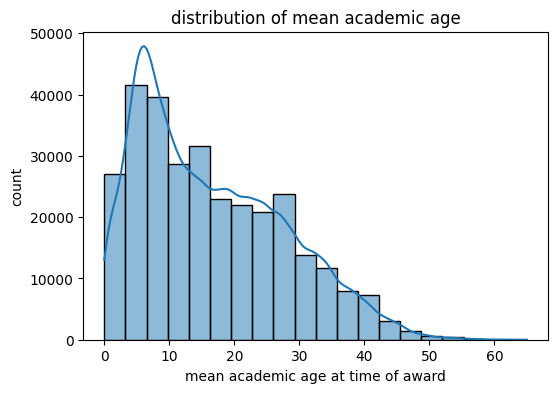

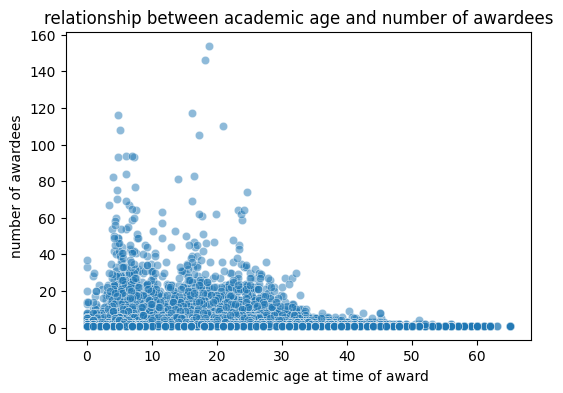

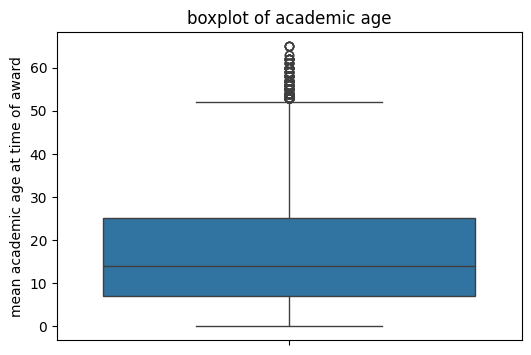

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

df = pd.read_csv('../dataset/Discipline Specific Pathways.csv', encoding='latin-1')

df.columns = df.columns.str.replace(r"\|", "", regex=True).str.strip()

#Drop columns with any missing values (as per the instructions)
df = df.dropna()

#Percentage to decimal conversion
if "Percentage of Awardees with This Award" in df.columns:
    df["Percentage of Awardees with This Award"] = (
        df["Percentage of Awardees with This Award"].str.replace("%", "", regex=True).astype(float) / 100
    )


df["# Awardees w/ This Award"] = df["# Awardees w/ This Award"].astype(int)
df["Mean Academic Age at Time of Award"] = df["Mean Academic Age at Time of Award"].astype(float)

df.to_csv("cleaned_discipline_specific_pathways.csv", index=False)

print("The data has been cleaned and saved as cleaned_discipline_specific_pathways.csv!")

# SUMMARY STATISTICS START HERE

# Summary statistics for the cleaned data
summary_stats = df.describe()
print(summary_stats)

# Histogram to see distribution of academic age
plt.figure(figsize=(6, 4))
sns.histplot(df["Mean Academic Age at Time of Award"], bins=20, kde=True)
plt.xlabel("mean academic age at time of award")
plt.ylabel("count")
plt.title("distribution of mean academic age")
plt.show()

# Scatter plot to see relationship between academic age vs. number of awardees
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df["Mean Academic Age at Time of Award"], y=df["# Awardees w/ This Award"], alpha=0.5)
plt.xlabel("mean academic age at time of award")
plt.ylabel("number of awardees")
plt.title("relationship between academic age and number of awardees")
plt.show()

# Boxplot to check outliers in academic age
plt.figure(figsize=(6, 4))
sns.boxplot(y=df["Mean Academic Age at Time of Award"])
plt.ylabel("mean academic age at time of award")
plt.title("boxplot of academic age")
plt.show()
